<a href="https://colab.research.google.com/github/Rachelsong1777/Financial-Information/blob/main/FI_News_12months.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install praw pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 5.6 MB/s eta 0:00:00


In [5]:
!pip install asyncpraw nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.4/196.4 kB 4.9 MB/s eta 0:00:00


In [34]:
# ✅ 完整 Reddit 评论抓取流程（asyncpraw + 授权登录）
# 安装 asyncpraw：!pip install asyncpraw

import asyncio
import asyncpraw
from urllib.parse import quote
from datetime import datetime
import pandas as pd
import nest_asyncio

nest_asyncio.apply()

# ========== 第一步：初始化 Reddit 客户端（Installed App） ==========
reddit = asyncpraw.Reddit(
    client_id="GMDy9mcNIwOwE83PC_gWXQ",          # ⚠️ 替换成 client_id
    client_secret="",                            # Installed App 必须为空字符串
    redirect_uri="https://www.google.com",
    user_agent="script:tesla-sentiment:v1.0 (by u/AccomplishedMeet6434)"  # ⚠️ 修改用户名
)

# ========== 第二步：创建授权链接 ==========
scopes = ["read"]
auth_url = reddit.auth.url(scopes=scopes, state="tesla", duration="permanent")
print("🔗 请访问以下链接进行授权（复制到浏览器中打开）:\n")
print(auth_url)

# 授权后，浏览器会跳转到：http://localhost:8080/?state=tesla&code=XXXX
# 请从 URL 中复制 code（例如 code=XXXX）并粘贴在此处：
code = "BVp5i3G7jn9KVAWaU1Y-SqqtGDF0xA"  # ⚠️ 替换成实际的授权码

# ========== 第三步：使用 code 获取授权 ==========
async def authorize():
    try:
        await reddit.auth.authorize(code)
        print("✅ 授权成功！")
    except Exception as e:
        print(f"❌ 授权失败: {e}")

# ========== 第四步：抓取 Tesla 评论数据 ==========
async def fetch_tesla_comments():
    subreddit = await reddit.subreddit("TeslaMotors")
    print("🚗 正在抓取 TeslaMotors 子版块的评论...")
    comments_data = []

    async for submission in subreddit.top(time_filter="year", limit=20):
        await submission.load()
        await submission.comments.replace_more(limit=0)
        for comment in submission.comments:
            if hasattr(comment, 'body'):
                comments_data.append({
                    "post_title": submission.title,
                    "comment": comment.body[:500],
                    "score": comment.score,
                    "created_utc": comment.created_utc,
                    "created_time": datetime.utcfromtimestamp(comment.created_utc)  # ✅ 新增标准时间戳
                })

    print(f"✅ 抓取完成，共抓取 {len(comments_data)} 条评论")
    return comments_data

# ========== 第五步：主运行逻辑 ==========
async def main():
    await authorize()
    data = await fetch_tesla_comments()

    df = pd.DataFrame(data)
    df.to_csv("tesla_reddit_comments.csv", index=False, encoding="utf-8-sig")
    print("💾 已保存为 tesla_reddit_comments.csv")

# ========== 执行 ==========
await main()



🔗 请访问以下链接进行授权（复制到浏览器中打开）:

https://www.reddit.com/api/v1/authorize?client_id=GMDy9mcNIwOwE83PC_gWXQ&duration=permanent&redirect_uri=https://www.google.com&response_type=code&scope=read&state=tesla
✅ 授权成功！
🚗 正在抓取 TeslaMotors 子版块的评论...


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7d58d5bf38d0>


✅ 抓取完成，共抓取 2103 条评论
💾 已保存为 tesla_reddit_comments.csv


In [27]:
# ✅ 抓取过去一年每月的 Tesla 热门帖及评论（按帖时间分月保存）
# 用 submission.created_utc 判断所属月份，确保分月数据准确

import asyncio
import asyncpraw
from datetime import datetime
import pandas as pd
import nest_asyncio
import os
from collections import defaultdict

nest_asyncio.apply()

reddit = asyncpraw.Reddit(
    client_id="GMDy9mcNIwOwE83PC_gWXQ",
    client_secret="",
    redirect_uri="https://www.google.com",
    user_agent="script:tesla-sentiment:v1.0 (by u/AccomplishedMeet6434)"
)

# Tesla 关键词
tesla_keywords = [
    "tesla", "elon musk", "musk", "$TSLA", "tsla", "model 3", "model y",
    "model s", "model x", "cybertruck", "autopilot", "fsd", "gigafactory",
    "tesla crash", "tesla earnings", "tesla layoff", "tesla delivery"
]

subreddits = ["TeslaMotors", "stocks", "wallstreetbets", "investing", "technology"]

# 工具函数

def is_tesla_related(text):
    text = text.lower()
    return any(keyword in text for keyword in tesla_keywords)

def get_12_month_keys():
    months = []
    now = datetime.now()
    for i in range(12):
        dt = now.replace(day=15) - pd.DateOffset(months=i)
        months.append(dt.strftime("%Y_%m"))
    return set(months)

# 主函数
comments_by_month = defaultdict(list)
post_ids_seen = set()
data_dir = "reddit_tesla_comments_monthly_real"
os.makedirs(data_dir, exist_ok=True)

async def fetch_by_created_time():
    print("🚀 开始抓取最近一年的 Tesla 评论数据（按帖子发表时间归档）")
    target_months = get_12_month_keys()

    for sub in subreddits:
        print(f"\n🔍 抓取 Subreddit: r/{sub}")
        subreddit = await reddit.subreddit(sub)

        async for submission in subreddit.top(time_filter="year", limit=300):
            await submission.load()
            created_month = datetime.utcfromtimestamp(submission.created_utc).strftime("%Y_%m")
            if created_month not in target_months:
                continue  # 只保留一年内的

            if submission.id in post_ids_seen:
                continue  # 避免重复
            post_ids_seen.add(submission.id)

            await submission.comments.replace_more(limit=0)
            count = 0
            for comment in submission.comments:
                if hasattr(comment, 'body') and is_tesla_related(comment.body):
                    comments_by_month[created_month].append({
                        "subreddit": sub,
                        "post_title": submission.title,
                        "comment": comment.body.strip(),
                        "score": comment.score,
                        "created_utc": comment.created_utc,
                        "created_time": datetime.utcfromtimestamp(comment.created_utc)
                    })
                    count += 1
                    if count >= 20:
                        break

    # 保存结果
    for month, comments in comments_by_month.items():
        df = pd.DataFrame(comments)
        path = os.path.join(data_dir, f"reddit_tesla_comments_{month}.csv")
        df.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"✅ 保存 {path}，共 {len(df)} 条评论")

# 运行
await fetch_by_created_time()


🚀 开始抓取最近一年的 Tesla 评论数据（按帖子发表时间归档）

🔍 抓取 Subreddit: r/TeslaMotors


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7d58de2e0590>



🔍 抓取 Subreddit: r/stocks

🔍 抓取 Subreddit: r/wallstreetbets

🔍 抓取 Subreddit: r/investing

🔍 抓取 Subreddit: r/technology
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_05.csv，共 1140 条评论
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_06.csv，共 673 条评论
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_10.csv，共 793 条评论
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_11.csv，共 662 条评论
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_07.csv，共 592 条评论
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_09.csv，共 486 条评论
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_08.csv，共 444 条评论
✅ 保存 reddit_tesla_comments_monthly_real/reddit_tesla_comments_2024_12.csv，共 395 条评论


In [29]:
# ✅ 抓取最近几个月（2025_01 到当前月）的 Tesla Reddit 热门帖及评论
# 用 submission.created_utc 判断归属月份，仅抓取缺失月份

import asyncio
import asyncpraw
from datetime import datetime
import pandas as pd
import nest_asyncio
import os
from collections import defaultdict

nest_asyncio.apply()

reddit = asyncpraw.Reddit(
    client_id="GMDy9mcNIwOwE83PC_gWXQ",
    client_secret="",
    redirect_uri="https://www.google.com",
    user_agent="script:tesla-sentiment:v1.0 (by u/AccomplishedMeet6434)"
)

# Tesla 关键词
tesla_keywords = [
    "tesla", "elon musk", "musk", "$TSLA", "tsla", "model 3", "model y",
    "model s", "model x", "cybertruck", "autopilot", "fsd", "gigafactory",
    "tesla crash", "tesla earnings", "tesla layoff", "tesla delivery"
]

subreddits = ["TeslaMotors", "stocks", "wallstreetbets", "investing", "technology"]

def is_tesla_related(text):
    text = text.lower()
    return any(keyword in text for keyword in tesla_keywords)

# 🔍 只抓取这几个目标月份
recent_target_months = ["2025_01", "2025_02", "2025_03", "2025_04"]
comments_by_month = defaultdict(list)
post_ids_seen = set()
data_dir = "reddit_tesla_comments_monthly_real"
os.makedirs(data_dir, exist_ok=True)

async def fetch_recent_months():
    print("🚀 抓取 2025 年最近几个月的 Tesla 热门评论")

    for sub in subreddits:
        print(f"\n🔍 抓取 Subreddit: r/{sub}")
        subreddit = await reddit.subreddit(sub)

        async for submission in subreddit.top(time_filter="year", limit=300):
            await submission.load()
            created_month = datetime.utcfromtimestamp(submission.created_utc).strftime("%Y_%m")
            if created_month not in recent_target_months:
                continue

            if submission.id in post_ids_seen:
                continue
            post_ids_seen.add(submission.id)

            await submission.comments.replace_more(limit=0)
            count = 0
            for comment in submission.comments:
                if hasattr(comment, 'body') and is_tesla_related(comment.body):
                    comments_by_month[created_month].append({
                        "subreddit": sub,
                        "post_title": submission.title,
                        "comment": comment.body.strip(),
                        "score": comment.score,
                        "created_utc": comment.created_utc,
                        "created_time": datetime.utcfromtimestamp(comment.created_utc)
                    })
                    count += 1
                    if count >= 20:
                        break

    for month, comments in comments_by_month.items():
        df = pd.DataFrame(comments)
        path = os.path.join(data_dir, f"reddit_tesla_hot_comments_{month}.csv")
        df.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"✅ 保存 {path}，共 {len(df)} 条评论")

# 执行
await fetch_recent_months()

🚀 抓取 2025 年最近几个月的 Tesla 热门评论

🔍 抓取 Subreddit: r/TeslaMotors


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7d58f07e7d50>



🔍 抓取 Subreddit: r/stocks

🔍 抓取 Subreddit: r/wallstreetbets

🔍 抓取 Subreddit: r/investing

🔍 抓取 Subreddit: r/technology


In [32]:
# ✅ 强化版：每月抓满 2000 条 Tesla 高质量评论（多轮补充 + 放宽过滤 + 多 subreddit）

import asyncio
import asyncpraw
from datetime import datetime
import pandas as pd
import nest_asyncio
import os
from collections import defaultdict

nest_asyncio.apply()

reddit = asyncpraw.Reddit(
    client_id="GMDy9mcNIwOwE83PC_gWXQ",
    client_secret="",
    redirect_uri="https://www.google.com",
    user_agent="script:tesla-sentiment:v1.0 (by u/AccomplishedMeet6434)"
)

# Tesla 关键词
tesla_keywords = [
    "tesla", "elon musk", "musk", "$TSLA", "tsla", "model 3", "model y",
    "model s", "model x", "cybertruck", "autopilot", "fsd", "gigafactory",
    "tesla crash", "tesla earnings", "tesla layoff", "tesla delivery"
]

# 扩展 subreddit 范围
subreddits = [
    "TeslaMotors", "stocks", "wallstreetbets", "investing", "technology",
    "cars", "electricvehicles", "finance", "business", "cryptocurrency", "Futurology"
]

def is_tesla_related(text):
    text = text.lower()
    return any(keyword in text for keyword in tesla_keywords)

def get_target_months():
    now = datetime.now()
    return [(now.replace(day=15) - pd.DateOffset(months=i)).strftime("%Y_%m") for i in range(12)][::-1]

async def fetch_monthly_comments_max_2000():
    data_dir = "reddit_tesla_comments_strong_filled"
    os.makedirs(data_dir, exist_ok=True)
    print("🚀 强化抓取：每月尽量补满 2000 条高质量 Tesla 评论")

    for month in get_target_months():
        print(f"\n📅 抓取月份: {month}")
        comments = []
        post_ids_seen = set()
        month_dt = pd.to_datetime(month, format="%Y_%m")

        # Step 1: 抓热门帖子评论
        for sub in subreddits:
            subreddit = await reddit.subreddit(sub)
            async for submission in subreddit.top(time_filter="year", limit=600):
                created_month = datetime.utcfromtimestamp(submission.created_utc).strftime("%Y_%m")
                if created_month != month or submission.id in post_ids_seen:
                    continue
                post_ids_seen.add(submission.id)
                await submission.load()
                await submission.comments.replace_more(limit=0)
                for comment in submission.comments:
                    if (hasattr(comment, 'body') and is_tesla_related(comment.body)
                        and comment.score >= 1 and len(comment.body) >= 20):
                        comments.append({
                            "subreddit": sub,
                            "post_title": submission.title,
                            "comment": comment.body.strip(),
                            "score": comment.score,
                            "reply_count": len(comment.replies),
                            "created_utc": comment.created_utc,
                            "created_time": datetime.utcfromtimestamp(comment.created_utc)
                        })

        # Step 2: 若不足 2000，进行多轮补充（最多 3 轮）
        max_rounds = 3
        round_count = 0
        while len(comments) < 2000 and round_count < max_rounds:
            round_count += 1
            print(f"🔁 新帖补充第 {round_count} 轮...")
            for sub in subreddits:
                subreddit = await reddit.subreddit(sub)
                async for submission in subreddit.new(limit=3000):
                    created_month = datetime.utcfromtimestamp(submission.created_utc).strftime("%Y_%m")
                    if created_month != month or submission.id in post_ids_seen:
                        continue
                    post_ids_seen.add(submission.id)
                    await submission.load()
                    await submission.comments.replace_more(limit=0)
                    for comment in submission.comments:
                        if (hasattr(comment, 'body') and is_tesla_related(comment.body)
                            and comment.score >= 1 and len(comment.body) >= 20):
                            comments.append({
                                "subreddit": sub,
                                "post_title": submission.title,
                                "comment": comment.body.strip(),
                                "score": comment.score,
                                "reply_count": len(comment.replies),
                                "created_utc": comment.created_utc,
                                "created_time": datetime.utcfromtimestamp(comment.created_utc)
                            })
                            if len(comments) >= 2000:
                                break
                    if len(comments) >= 2000:
                        break
                if len(comments) >= 2000:
                    break

        # Step 3: 保存（按 score 降序截断）
        sorted_comments = sorted(comments, key=lambda x: x['score'], reverse=True)[:2000]
        df = pd.DataFrame(sorted_comments)
        path = os.path.join(data_dir, f"reddit_tesla_comments_{month}.csv")
        df.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"✅ 已保存 {path}，共 {len(df)} 条评论")

# 执行
await fetch_monthly_comments_max_2000()

🚀 强化抓取：每月尽量补满 2000 条高质量 Tesla 评论

📅 抓取月份: 2024_05


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7d58d3febc90>


✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_05.csv，共 2000 条评论

📅 抓取月份: 2024_06
🔁 新帖补充第 1 轮...
🔁 新帖补充第 2 轮...
🔁 新帖补充第 3 轮...
✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_06.csv，共 1732 条评论

📅 抓取月份: 2024_07
✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_07.csv，共 2000 条评论

📅 抓取月份: 2024_08
🔁 新帖补充第 1 轮...
🔁 新帖补充第 2 轮...
🔁 新帖补充第 3 轮...
✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_08.csv，共 1967 条评论

📅 抓取月份: 2024_09
🔁 新帖补充第 1 轮...
🔁 新帖补充第 2 轮...
🔁 新帖补充第 3 轮...
✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_09.csv，共 1534 条评论

📅 抓取月份: 2024_10
✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_10.csv，共 2000 条评论

📅 抓取月份: 2024_11
✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_11.csv，共 2000 条评论

📅 抓取月份: 2024_12
🔁 新帖补充第 1 轮...
🔁 新帖补充第 2 轮...
🔁 新帖补充第 3 轮...
✅ 已保存 reddit_tesla_comments_strong_filled/reddit_tesla_comments_2024_12.csv，共 1015 条评论

📅 抓取

In [30]:
import os
import pandas as pd

folder_path = "/content/monthly"  # 替换为 Colab 文件目录
monthly_sample_files = [f for f in os.listdir(folder_path) if f.startswith("reddit_tesla_comments_")]

# 合并 2000 条/月 数据
monthly_dfs = []
for file in monthly_sample_files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df["source_type"] = "monthly_sample"
    monthly_dfs.append(df)
monthly_df = pd.concat(monthly_dfs, ignore_index=True)

folder_path = "/content/hot"
hot_post_files = [f for f in os.listdir(folder_path) if f.startswith("reddit_tesla_hot_")]

# 合并热帖数据
hot_dfs = []
for file in hot_post_files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df["source_type"] = "hot_posts"
    hot_dfs.append(df)
hot_df = pd.concat(hot_dfs, ignore_index=True)

# 保存合并后的文件
monthly_df.to_csv("/content/reddit_tesla_monthly_all.csv", index=False)
hot_df.to_csv("/content/reddit_tesla_hot_all.csv", index=False)


In [31]:
import pandas as pd
import os
import re

# Tesla 关键词
tesla_keywords = [
    "tesla", "elon musk", "musk", "$tsla", "tsla", "model 3", "model y",
    "model s", "model x", "cybertruck", "autopilot", "fsd", "gigafactory",
    "tesla crash", "tesla earnings", "tesla layoff", "tesla delivery"
]

# 判断评论或标题是否涉及 Tesla
def is_tesla_related(text):
    text = str(text).lower()
    return any(keyword in text for keyword in tesla_keywords)

# 文本清洗函数（保留空格）
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)       # 去链接
    text = re.sub(r"[^\x00-\x7F]+", "", text)            # 去 emoji、非英文字符
    text = re.sub(r"\s+", " ", text).strip()            # 合并多余空格
    return text

# 主清洗函数
def clean_comments(df):
    # 日期字段处理
    if "created_time" in df.columns:
        df["created_time"] = pd.to_datetime(df["created_time"], errors="coerce").dt.date

    # 丢弃空值和重复评论
    df = df.dropna(subset=["comment"])
    df = df.drop_duplicates(subset=["comment"])

    # 清洗评论和标题
    df["comment_clean"] = df["comment"].apply(clean_text)
    df["title_clean"] = df["post_title"].apply(clean_text) if "post_title" in df.columns else ""

    # 过滤太短的评论
    df = df[df["comment_clean"].str.len() > 10]

    # 关键词筛选
    df = df[df["comment_clean"].apply(is_tesla_related) | df["title_clean"].apply(is_tesla_related)]

    return df


In [33]:
# 处理目标文件列表
files_to_clean = {
    "reddit_tesla_monthly_all.csv": "/content/reddit_tesla_monthly_all_cleaned.csv",
    "reddit_tesla_hot_all.csv": "/content/reddit_tesla_hot_all_cleaned.csv",
    "tesla_reddit_comments.csv": "/content/tesla_reddit_comments_cleaned.csv"
}

for input_file, output_file in files_to_clean.items():
    try:
        df = pd.read_csv(f"/content/{input_file}")
        df_cleaned = clean_comments(df)
        df_cleaned.to_csv(output_file, index=False, encoding="utf-8-sig")
        print(f"✅ 已清洗并保存: {output_file}（剩余 {len(df_cleaned)} 条评论）")
    except Exception as e:
        print(f"❌ 清洗失败 {input_file}: {e}")


✅ 已清洗并保存: /content/reddit_tesla_monthly_all_cleaned.csv（剩余 19061 条评论）
✅ 已清洗并保存: /content/reddit_tesla_hot_all_cleaned.csv（剩余 4978 条评论）
✅ 已清洗并保存: /content/tesla_reddit_comments_cleaned.csv（剩余 1705 条评论）


In [17]:
import nltk
nltk.download('opinion_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00


In [39]:
import pandas as pd
from nltk.corpus import opinion_lexicon
from nltk.tokenize import word_tokenize

# 初始化情绪词典
positive_words = set(opinion_lexicon.positive())
negative_words = set(opinion_lexicon.negative())

# 定义函数
def add_nltk_sentiment_counts(
    df,
    text_col="comment_clean",
    output_path=None
):
    def count_sentiment_words(text):
        words = word_tokenize(str(text).lower())
        pos_count = sum(1 for word in words if word in positive_words)
        neg_count = sum(1 for word in words if word in negative_words)
        return pd.Series([pos_count, neg_count])

    df[["positive_word_count", "negative_word_count"]] = df[text_col].apply(count_sentiment_words)

    if output_path:
        df.to_csv(output_path, index=False)
        print(f"✅ 已完成 NLTK 情绪统计并保存至：{output_path}")

    return df


In [40]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def add_vader_sentiment_counts(
    df,
    text_col="comment_clean",
    output_path=None
):
    def vader_score(text):
        scores = analyzer.polarity_scores(str(text))
        return pd.Series([scores['pos'] * 10, scores['neg'] * 10])

    df[["positive_word_count", "negative_word_count"]] = df[text_col].apply(vader_score)

    if output_path:
        df.to_csv(output_path, index=False)
        print(f"✅ 已完成 VADER 情绪分析并保存至：{output_path}")

    return df


✅ 已保存非加权日情绪分析数据：/content/daily_sentiment_unweighted_monthly_nltk.csv


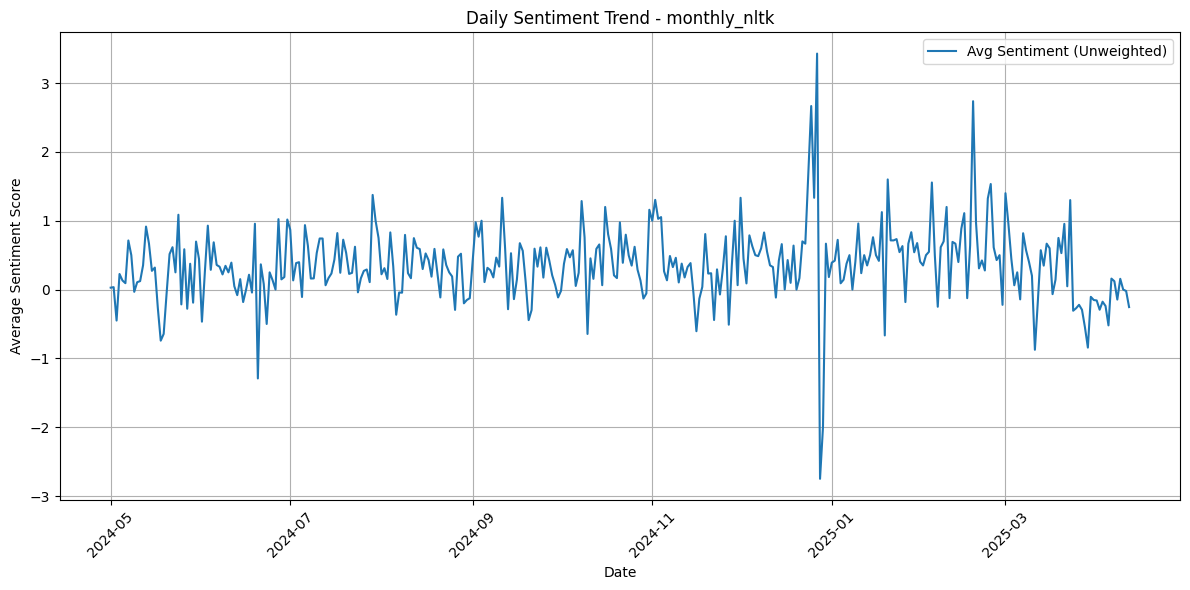

🖼️ 图像已保存：/content/daily_sentiment_unweighted_monthly_nltk.png
✅ 已保存非加权日情绪分析数据：/content/daily_sentiment_unweighted_monthly_vader.csv


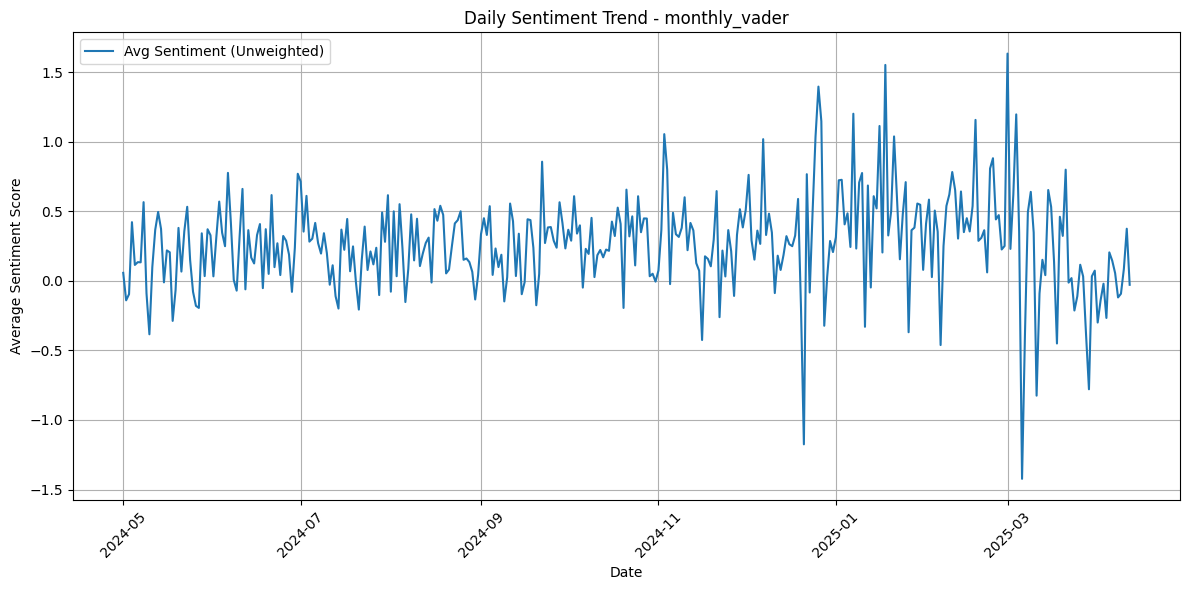

🖼️ 图像已保存：/content/daily_sentiment_unweighted_monthly_vader.png


In [41]:
# 读取主集数据
df_monthly = pd.read_csv("/content/cleaned/reddit_tesla_monthly_all_cleaned.csv")

# 应用 NLTK
df_monthly_nltk = add_nltk_sentiment_counts(df_monthly.copy())
daily_nltk = analyze_sentiment_unweighted(df_monthly_nltk, dataset_name="monthly_nltk")

# 应用 VADER
df_monthly_vader = add_vader_sentiment_counts(df_monthly.copy())
daily_vader = analyze_sentiment_unweighted(df_monthly_vader, dataset_name="monthly_vader")


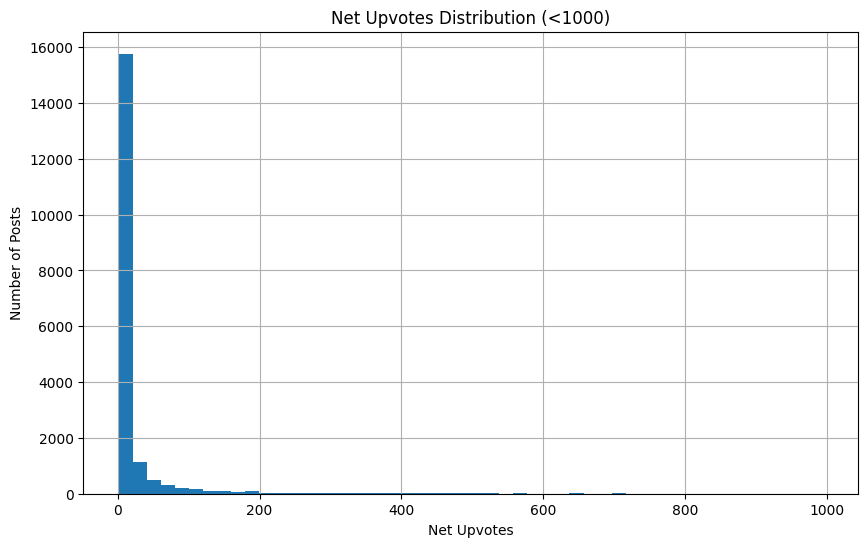

点赞数分布分位数：
0.25      1.0
0.50      3.0
0.75     12.0
0.90     49.0
0.95    124.0
0.99    703.6
Name: score, dtype: float64


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据（请根据实际路径调整）
df = pd.read_csv("/content/cleaned/reddit_tesla_monthly_all_cleaned.csv")

# 去除负值，避免错误
df = df[df['score'] >= 0]

# 绘制点赞分布图（限制极端值以清晰展示主流分布）
plt.figure(figsize=(10,6))
df[df['score'] < 1000]['score'].hist(bins=50)
plt.title('Net Upvotes Distribution (<1000)')
plt.xlabel('Net Upvotes')
plt.ylabel('Number of Posts')
plt.grid(True)

# ✅ 保存图像
plt.savefig("/content/net_upvotes_distribution_under_1000.png", dpi=300)
plt.show()

# 打印简单分位数参考
print("点赞数分布分位数：")
print(df['score'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_propagation_multiplier(score):
    """按点赞数分层返回传播系数"""
    if score <= 3:
        return 1.0
    elif score <= 12:
        return 1.1
    elif score <= 49:
        return 1.3
    elif score <= 124:
        return 1.6
    elif score <= 703:
        return 1.8
    else:
        return 2.0

def analyze_sentiment_weighted(
    df,
    dataset_name="tesla_reddit",
    pos_col="positive_word_count",
    neg_col="negative_word_count",
    score_col="score",                 # 点赞列
    date_col="created_time",           # 时间列
    output_dir="/content"
):
    # 1. 创建原始情绪得分列
    df["sentiment_score"] = df[pos_col] - df[neg_col]

    # 2. 添加传播系数列
    df["multiplier"] = df[score_col].apply(compute_propagation_multiplier)

    # 3. 计算加权情绪得分
    df["weighted_sentiment"] = df["sentiment_score"] * df["multiplier"]

    # 4. 确保时间格式为 datetime.date
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce").dt.date

    # 5. 日聚合
    daily = df.groupby(date_col).agg({
        "weighted_sentiment": "mean",
        "sentiment_score": "mean",
        score_col: "mean",
        date_col: "count"
    }).rename(columns={date_col: "comment_count"}).reset_index()

    # 6. 保存 CSV
    output_csv = f"{output_dir}/daily_sentiment_weighted_{dataset_name}.csv"
    daily.to_csv(output_csv, index=False)
    print(f"✅ 已保存加权日情绪数据：{output_csv}")

    # 7. 绘图并保存
    plt.figure(figsize=(12,6))
    plt.plot(daily[date_col], daily["weighted_sentiment"], label="Weighted Sentiment Score")
    plt.title(f"Daily Weighted Sentiment - {dataset_name}")
    plt.xlabel("Date")
    plt.ylabel("Weighted Sentiment")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    output_img = f"{output_dir}/daily_sentiment_weighted_{dataset_name}.png"
    plt.savefig(output_img, dpi=300)
    plt.show()
    print(f"🖼️ 图像已保存：{output_img}")

    return daily


In [47]:
# 对清洗后的 monthly 数据集生成情绪词数量字段
df_monthly = pd.read_csv("/content/cleaned/reddit_tesla_monthly_all_cleaned.csv")

# 生成 nltk 版本
df_monthly_nltk = add_nltk_sentiment_counts(df_monthly.copy())
df_monthly_nltk.to_csv("/content/nltk_vader/reddit_tesla_monthly_all_cleaned_with_nltk.csv", index=False)

# 生成 vader 版本
df_monthly_vader = add_vader_sentiment_counts(df_monthly.copy())
df_monthly_vader.to_csv("/content/nltk_vader/reddit_tesla_monthly_all_cleaned_with_vader.csv", index=False)


✅ 已保存加权日情绪数据：/content/daily_sentiment_weighted_monthly_nltk.csv


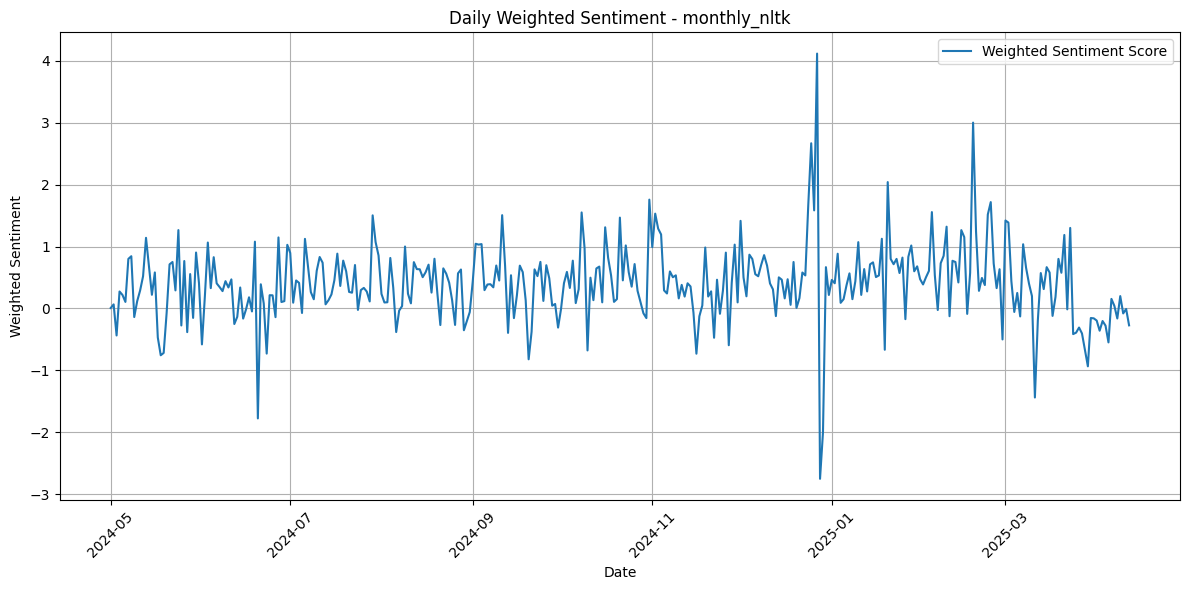

🖼️ 图像已保存：/content/daily_sentiment_weighted_monthly_nltk.png
✅ 已保存加权日情绪数据：/content/daily_sentiment_weighted_monthly_vader.csv


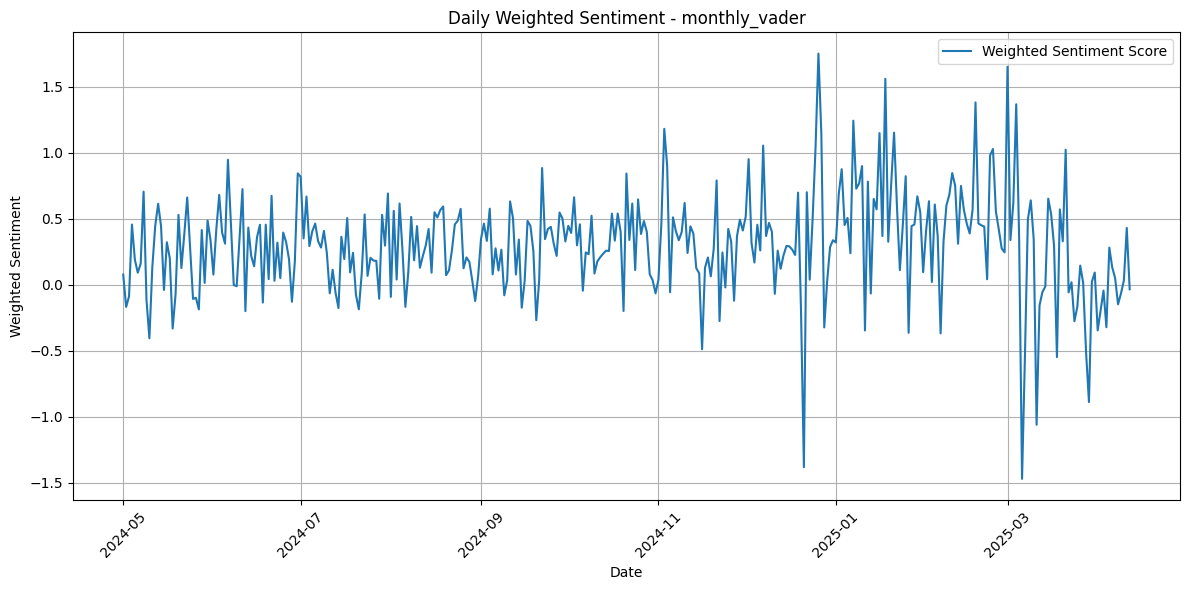

🖼️ 图像已保存：/content/daily_sentiment_weighted_monthly_vader.png


In [48]:
# 准备好两个版本的主集：
df_monthly_nltk = pd.read_csv("/content/nltk_vader/reddit_tesla_monthly_all_cleaned_with_nltk.csv")
df_monthly_vader = pd.read_csv("/content/nltk_vader/reddit_tesla_monthly_all_cleaned_with_vader.csv")

# 分别加权分析
daily_monthly_nltk_weighted = analyze_sentiment_weighted(
    df_monthly_nltk,
    dataset_name="monthly_nltk"
)

daily_monthly_vader_weighted = analyze_sentiment_weighted(
    df_monthly_vader,
    dataset_name="monthly_vader"
)

In [55]:
import matplotlib.pyplot as plt

def compare_nltk_vs_vader_sentiment(
    df_nltk,
    df_vader,
    sentiment_col="sentiment_score",  # or 'weighted_sentiment'
    date_col="created_time",
    dataset_name="monthly",
    output_dir="/content"
):
    df_nltk[date_col] = pd.to_datetime(df_nltk[date_col])
    df_vader[date_col] = pd.to_datetime(df_vader[date_col])

    # 绘图
    plt.figure(figsize=(14, 6))
    plt.plot(df_nltk[date_col], df_nltk[sentiment_col], label="NLTK", linewidth=1.5)
    plt.plot(df_vader[date_col], df_vader[sentiment_col], label="VADER", linewidth=1.5)
    plt.title(f"{sentiment_col.replace('_', ' ').title()} - NLTK vs VADER ({dataset_name})")
    plt.xlabel("Date")
    plt.ylabel("Sentiment Score")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 输出图像
    filename = f"{output_dir}/compare_nltk_vs_vader_{sentiment_col}_{dataset_name}.png"
    plt.savefig(filename, dpi=300)
    plt.show()
    print(f"🖼️ 已保存对比图：{filename}")


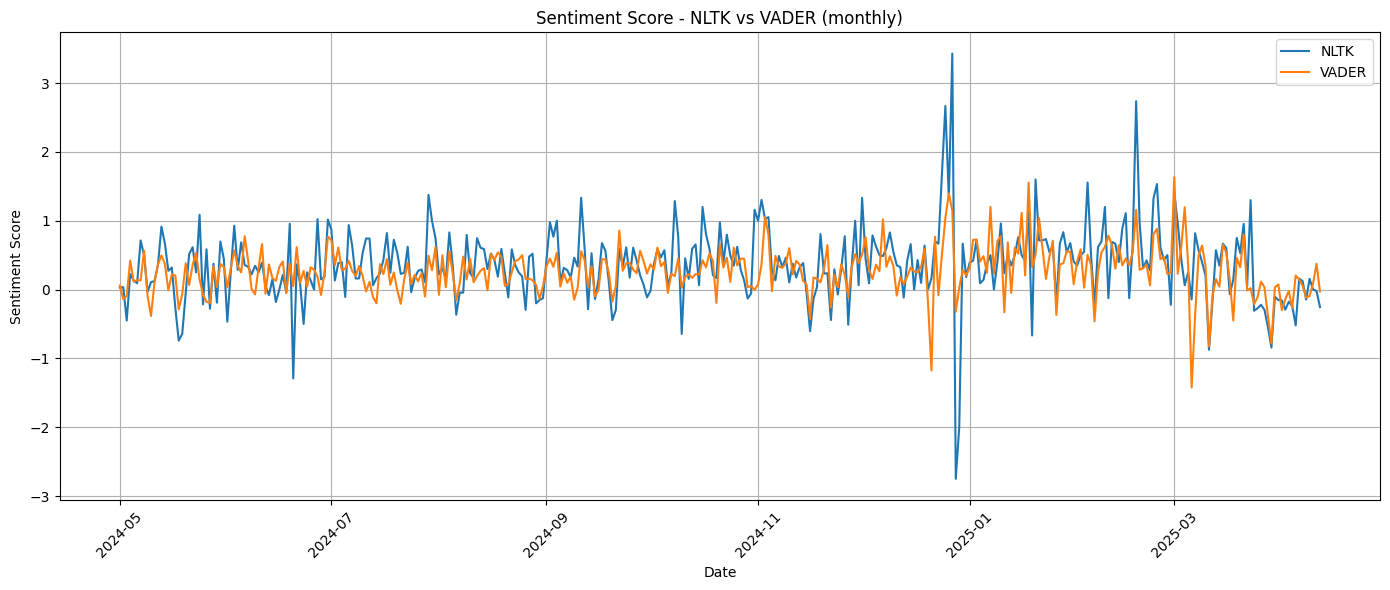

🖼️ 已保存对比图：/content/compare_nltk_vs_vader_sentiment_score_monthly.png


In [56]:
df_nltk_unweighted = pd.read_csv("/content/nltk_vader/daily_sentiment_unweighted_monthly_nltk.csv")
df_vader_unweighted = pd.read_csv("/content/nltk_vader/daily_sentiment_unweighted_monthly_vader.csv")

compare_nltk_vs_vader_sentiment(
    df_nltk_unweighted,
    df_vader_unweighted,
    sentiment_col="sentiment_score",
    dataset_name="monthly"
)


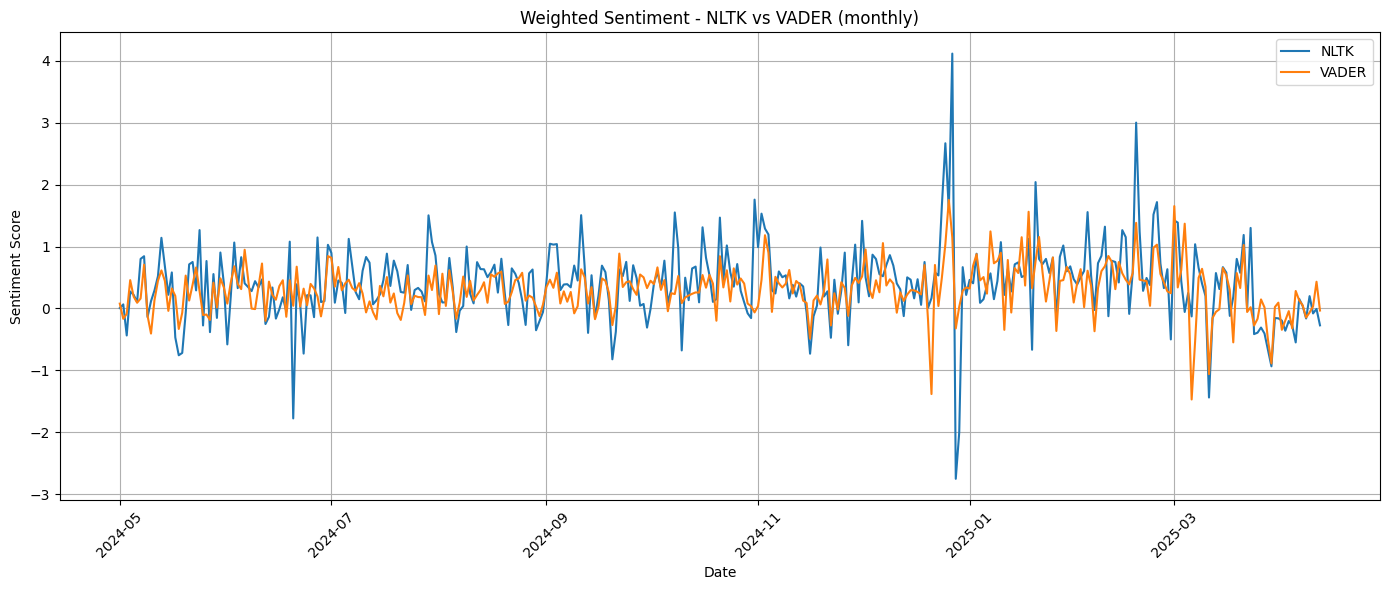

🖼️ 已保存对比图：/content/compare_nltk_vs_vader_weighted_sentiment_monthly.png


In [57]:
df_nltk_weighted = pd.read_csv("/content/nltk_vader/daily_sentiment_weighted_monthly_nltk.csv")
df_vader_weighted = pd.read_csv("/content/nltk_vader/daily_sentiment_weighted_monthly_vader.csv")

compare_nltk_vs_vader_sentiment(
    df_nltk_weighted,
    df_vader_weighted,
    sentiment_col="weighted_sentiment",
    dataset_name="monthly"
)


In [49]:
import matplotlib.pyplot as plt

def compare_unweighted_vs_weighted(
    df_unweighted, df_weighted,
    date_col="created_time",
    unweighted_col="sentiment_score",
    weighted_col="weighted_sentiment",
    dataset_name="monthly_vader",
    output_dir="/content"
):
    # 转换时间格式
    df_unweighted[date_col] = pd.to_datetime(df_unweighted[date_col])
    df_weighted[date_col] = pd.to_datetime(df_weighted[date_col])

    # 绘图
    plt.figure(figsize=(14, 6))
    plt.plot(df_unweighted[date_col], df_unweighted[unweighted_col], label="Unweighted", linewidth=1.5)
    plt.plot(df_weighted[date_col], df_weighted[weighted_col], label="Weighted", linewidth=1.5)
    plt.title(f"Unweighted vs Weighted Sentiment - {dataset_name}")
    plt.xlabel("Date")
    plt.ylabel("Average Sentiment Score")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 保存图像
    output_img = f"{output_dir}/compare_sentiment_{dataset_name}.png"
    plt.savefig(output_img, dpi=300)
    plt.show()
    print(f"🖼️ 已保存对比图：{output_img}")


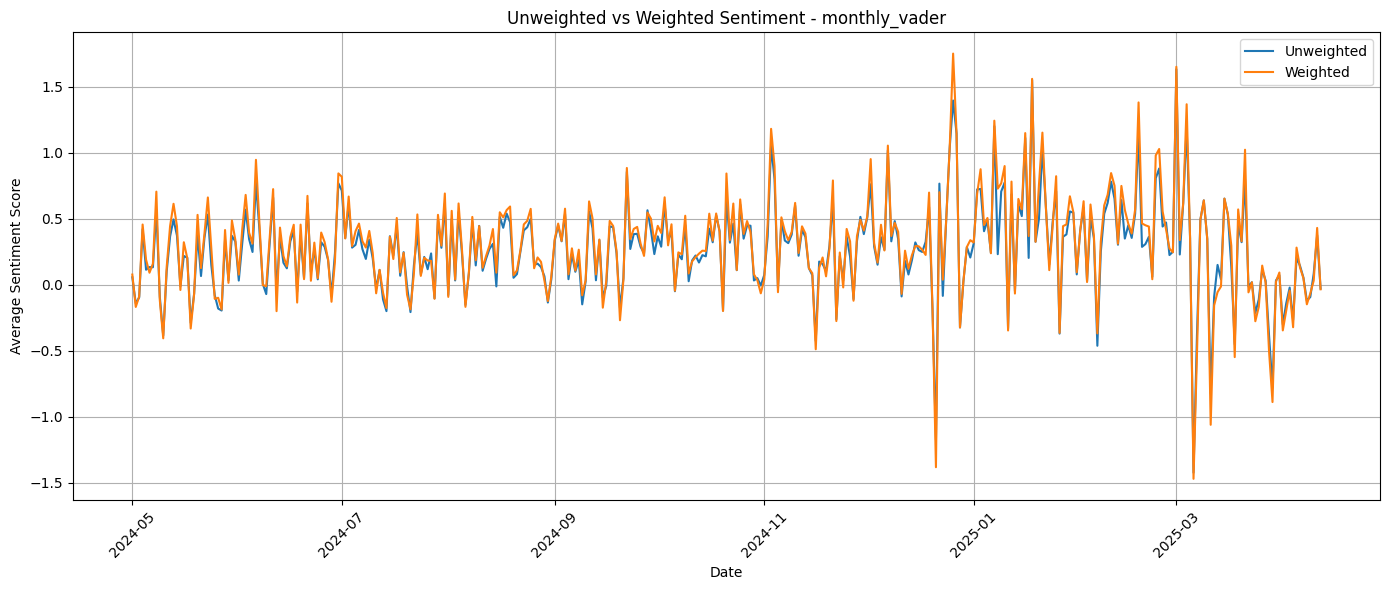

🖼️ 已保存对比图：/content/compare_sentiment_monthly_vader.png


In [58]:
df_unweighted = pd.read_csv("/content/nltk_vader/daily_sentiment_unweighted_monthly_vader.csv")
df_weighted = pd.read_csv("/content/nltk_vader/daily_sentiment_weighted_monthly_vader.csv")

compare_unweighted_vs_weighted(
    df_unweighted,
    df_weighted,
    dataset_name="monthly_vader"
)


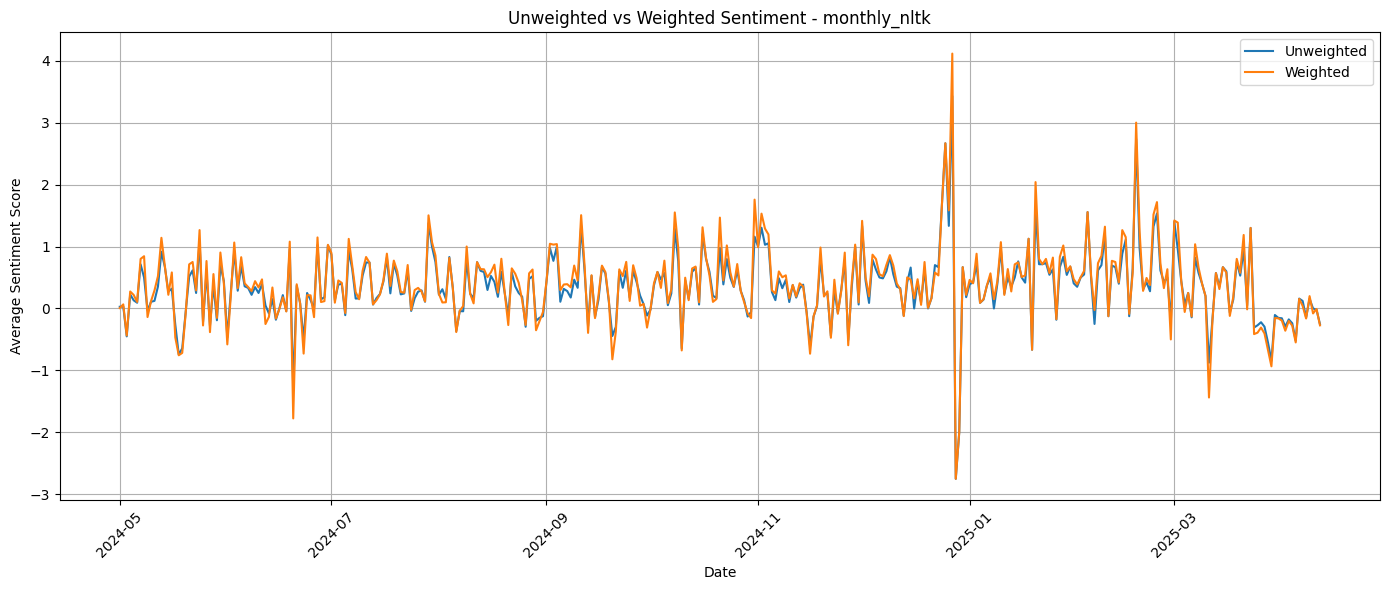

🖼️ 已保存对比图：/content/compare_sentiment_monthly_nltk.png


In [59]:
df_unweighted = pd.read_csv("/content/nltk_vader/daily_sentiment_unweighted_monthly_nltk.csv")
df_weighted = pd.read_csv("/content/nltk_vader/daily_sentiment_weighted_monthly_nltk.csv")

compare_unweighted_vs_weighted(
    df_unweighted,
    df_weighted,
    dataset_name="monthly_nltk"
)


In [61]:
def process_vader_sentiment_all(dataset_list):
    for name in dataset_list:
        try:
            if name == "hot":
                path = "/content/cleaned/reddit_tesla_hot_all_cleaned.csv"
                dataset_name = "hot_vader"
            elif name == "subreddit":
                path = "/content/cleaned/tesla_reddit_comments_cleaned.csv"
                dataset_name = "subreddit_vader"
            else:
                print(f"⚠️ 未知数据集名称：{name}，跳过")
                continue

            print(f"🚀 正在处理数据集：{dataset_name}")
            df = pd.read_csv(path)

            # 添加 VADER 情绪字段
            df = add_vader_sentiment_counts(df)

            # 进行传播加权分析
            analyze_sentiment_weighted(df, dataset_name=dataset_name)

            print(f"✅ 数据集 {dataset_name} 处理完成\n")

        except Exception as e:
            print(f"❌ 处理 {name} 失败：{e}")


🚀 正在处理数据集：hot_vader
✅ 已保存加权日情绪数据：/content/daily_sentiment_weighted_hot_vader.csv


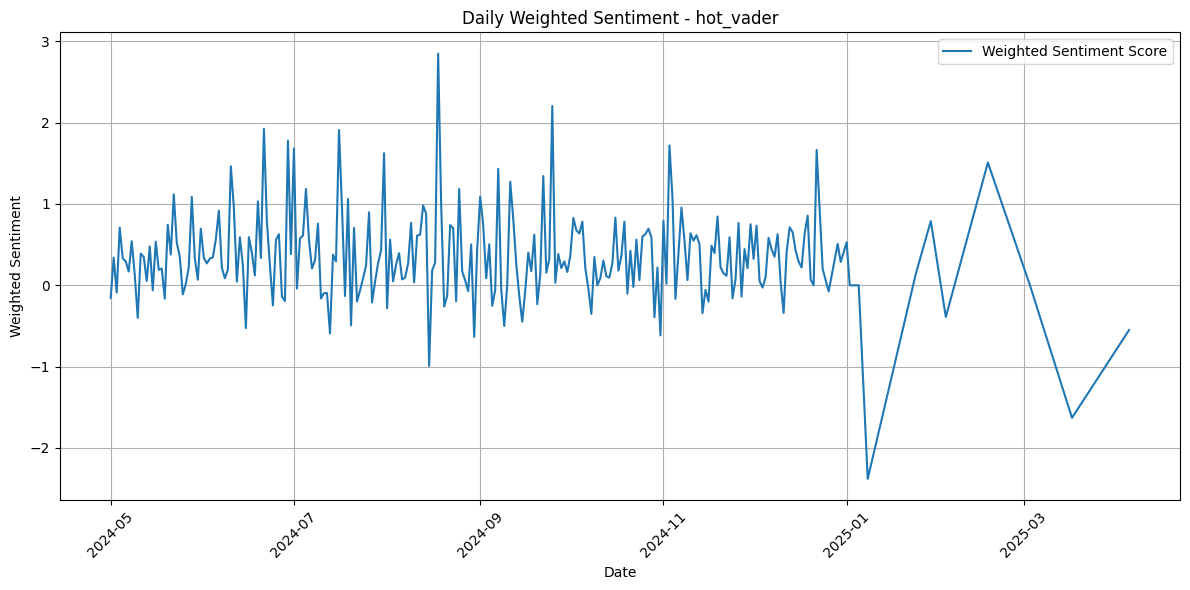

🖼️ 图像已保存：/content/daily_sentiment_weighted_hot_vader.png
✅ 数据集 hot_vader 处理完成

🚀 正在处理数据集：subreddit_vader
✅ 已保存加权日情绪数据：/content/daily_sentiment_weighted_subreddit_vader.csv


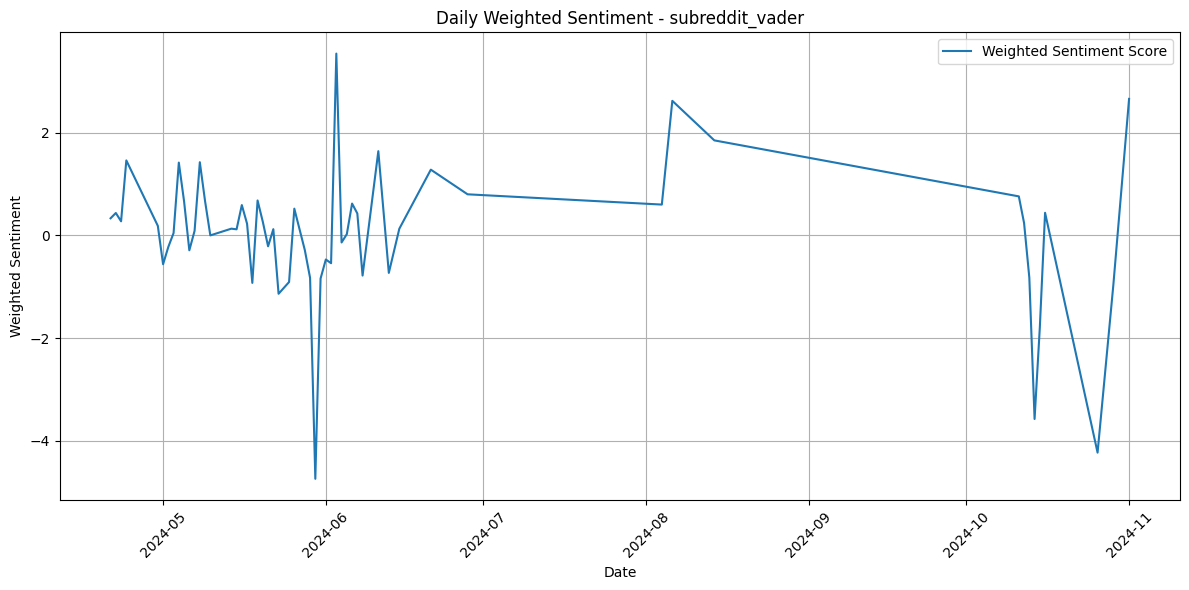

🖼️ 图像已保存：/content/daily_sentiment_weighted_subreddit_vader.png
✅ 数据集 subreddit_vader 处理完成



In [62]:
process_vader_sentiment_all(["hot", "subreddit"])

In [63]:
def analyze_sentiment_weighted_weekly(
    df,
    dataset_name="tesla_reddit",
    pos_col="positive_word_count",
    neg_col="negative_word_count",
    score_col="score",
    date_col="created_time",
    output_dir="/content"
):
    from datetime import datetime
    import matplotlib.pyplot as plt

    # 1. 情绪得分 + 传播系数
    df["sentiment_score"] = df[pos_col] - df[neg_col]
    df["multiplier"] = df[score_col].apply(compute_propagation_multiplier)
    df["weighted_sentiment"] = df["sentiment_score"] * df["multiplier"]

    # 2. 确保时间格式 & 获取周
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["week"] = df[date_col].dt.to_period("W").apply(lambda r: r.start_time)

    # 3. 周聚合
    weekly = df.groupby("week").agg({
        "weighted_sentiment": "mean",
        "sentiment_score": "mean",
        score_col: "mean",
        date_col: "count"
    }).rename(columns={date_col: "comment_count"}).reset_index()

    # 4. 保存 CSV
    output_csv = f"{output_dir}/weekly_sentiment_weighted_{dataset_name}.csv"
    weekly.to_csv(output_csv, index=False)
    print(f"✅ 已保存加权【周聚合】情绪数据：{output_csv}")

    # 5. 绘图
    plt.figure(figsize=(12,6))
    plt.plot(weekly["week"], weekly["weighted_sentiment"], label="Weekly Weighted Sentiment")
    plt.title(f"Weekly Weighted Sentiment - {dataset_name}")
    plt.xlabel("Week")
    plt.ylabel("Weighted Sentiment")
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    output_img = f"{output_dir}/weekly_sentiment_weighted_{dataset_name}.png"
    plt.savefig(output_img, dpi=300)
    plt.show()
    print(f"🖼️ 图像已保存：{output_img}")

    return weekly


✅ 已保存加权【周聚合】情绪数据：/content/weekly_sentiment_weighted_hot_vader.csv


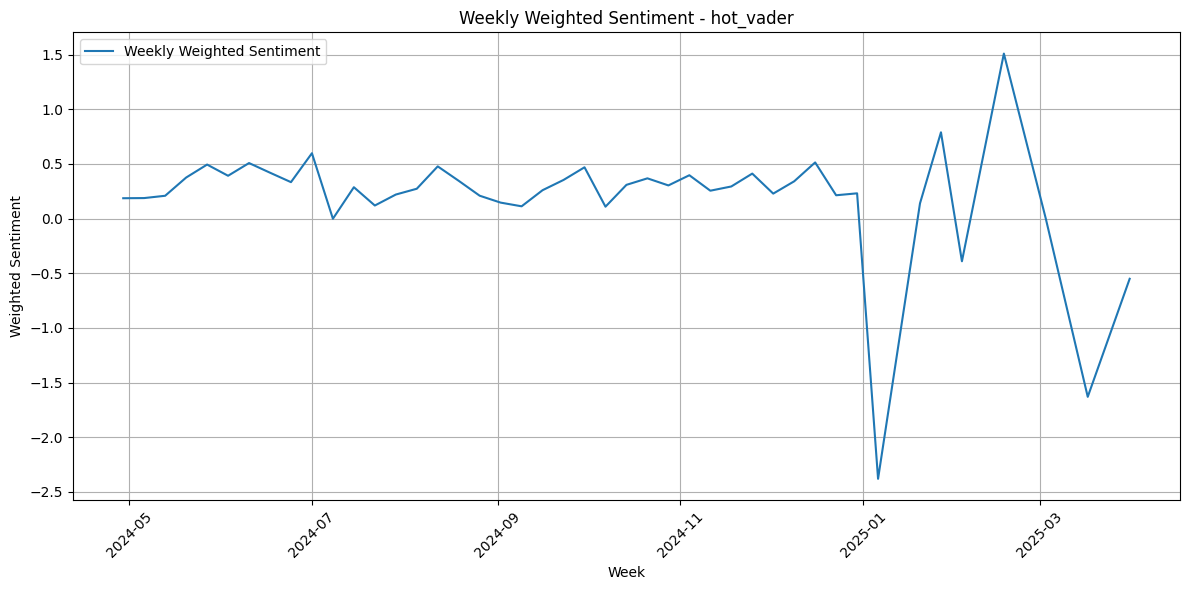

🖼️ 图像已保存：/content/weekly_sentiment_weighted_hot_vader.png
✅ 已保存加权【周聚合】情绪数据：/content/weekly_sentiment_weighted_subreddit_vader.csv


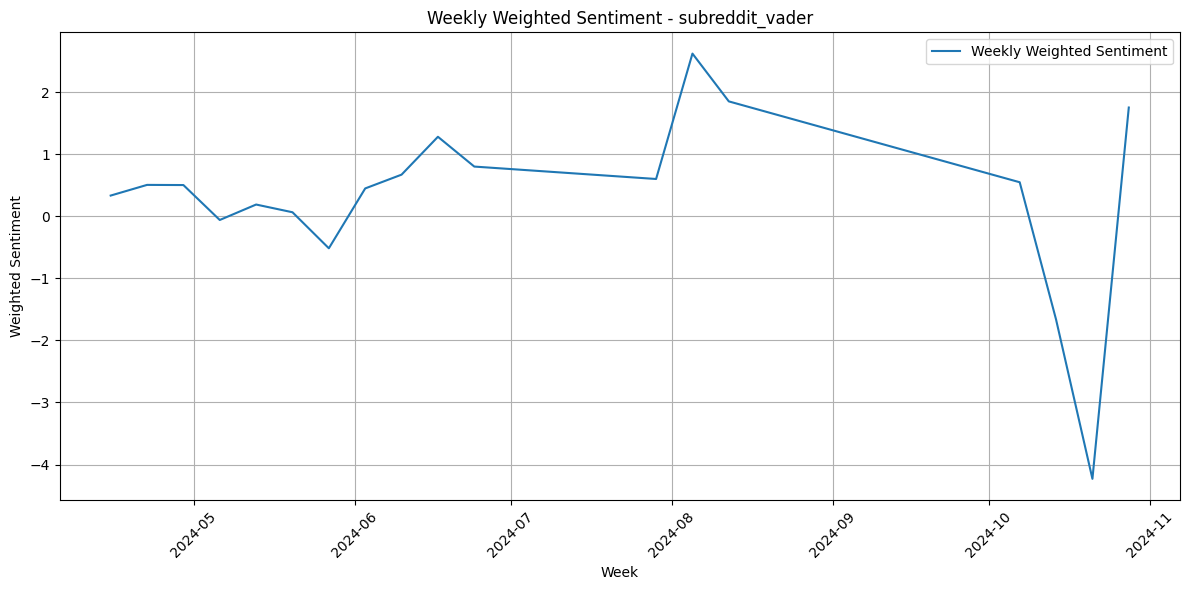

🖼️ 图像已保存：/content/weekly_sentiment_weighted_subreddit_vader.png


,week,weighted_sentiment,sentiment_score,score,comment_count
0,2024-04-15,0.332968,0.271494,13.551948,154
1,2024-04-22,0.504848,0.504848,1.030303,33
2,2024-04-29,0.502259,0.479270,24.485401,274
3,2024-05-06,-0.060463,-0.036829,36.024390,82
4,2024-05-13,0.188502,0.180145,19.369295,482
5,2024-05-20,0.063982,-0.008563,58.832335,167
6,2024-05-27,-0.516404,-0.401468,24.614679,109
7,2024-06-03,0.447918,0.371725,51.341176,255
8,2024-06-10,0.670000,0.670000,1.000000,4
9,2024-06-17,1.280000,1.280000,1.000000,1


In [64]:
df_hot = pd.read_csv("/content/cleaned/reddit_tesla_hot_all_cleaned.csv")
df_hot = add_vader_sentiment_counts(df_hot)
analyze_sentiment_weighted_weekly(df_hot, dataset_name="hot_vader")

df_sub = pd.read_csv("/content/cleaned/tesla_reddit_comments_cleaned.csv")
df_sub = add_vader_sentiment_counts(df_sub)
analyze_sentiment_weighted_weekly(df_sub, dataset_name="subreddit_vader")


总体情绪分布：
           Count  Percentage
sentiment                   
positive     267       76.95
negative      54       15.56
neutral       26        7.49


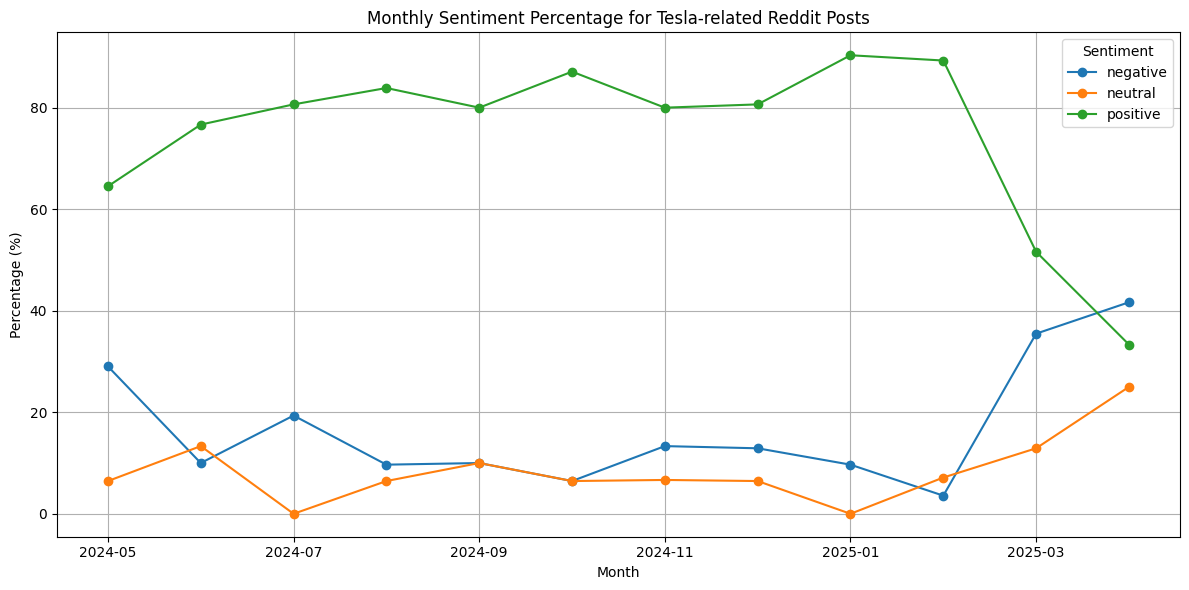

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取文件
df = pd.read_csv('/content/daily_sentiment_weighted_monthly_vader.csv')

# 情绪分类函数（基于 weighted_sentiment）
def classify_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# 应用情绪分类
df['sentiment'] = df['weighted_sentiment'].apply(classify_sentiment)

# 情绪分布统计（总体）
sentiment_counts = df['sentiment'].value_counts()
sentiment_percentages = df['sentiment'].value_counts(normalize=True) * 100
sentiment_summary = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': sentiment_percentages.round(2)
})
print("总体情绪分布：")
print(sentiment_summary)

# 添加月份字段
df['month'] = pd.to_datetime(df['created_time']).dt.to_period('M').astype(str)

# 按月统计情绪数量
monthly_sentiment_counts = df.groupby(['month', 'sentiment']).size().unstack(fill_value=0)

# 按月统计情绪百分比
monthly_sentiment_percent = monthly_sentiment_counts.div(monthly_sentiment_counts.sum(axis=1), axis=0) * 100

# 绘制情绪变化趋势图（百分比）
monthly_sentiment_percent.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Monthly Sentiment Percentage for Tesla-related Reddit Posts')
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.legend(title='Sentiment')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_sentiment_trend.png')  # 可选：保存图像
plt.show()


In [3]:
!pip install wordcloud

In [79]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('opinion_lexicon')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')
nltk.download('words')
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading packa

True

In [82]:
import os
import re
import random
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import opinion_lexicon, words, stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter

# 初始化
english_vocab = set(words.words())
nltk_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# 自定义停用词
extra_stopwords = set([
    'the', 'and', 'but', 'or', 'nor', 'so', 'for', 'yet', 'as', 'if', 'because', 'although', 'though', 'while',
    'with', 'without', 'within', 'from', 'then', 'that', 'which', 'whom', 'whose', 'than', 'of', 'in', 'on', 'at',
    'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
    'my', 'your', 'his', 'her', 'its', 'our', 'their', 'mine', 'yours', 'ours', 'theirs',
    'can', 'could', 'shall', 'should', 'will', 'would', 'may', 'might', 'must', 'do', 'does', 'did', 'have', 'has', 'had',
    'dont', 'cant', 'doesnt', 'didnt', 'havent', 'hasnt', 'hadnt',
    'just', 'really', 'very', 'maybe', 'perhaps', 'sure', 'even', 'more', 'many', 'much', 'most', 'such', 'quite',
    'like', 'also', 'often', 'always', 'sometimes', 'almost', 'already', 'still', 'yet', 'since', 'ever', 'ago',
    'actually', 'around', 'every', 'another', 'thats', 'we', 'back', 'next', 'right', 'last', 'first', 'month', 'week',
    'day', 'long', 'short', 'year', 'time', 'guy', 'gonna', 'wanna', 'point', 'vote', 'turn'
])

custom_stopwords = set([
    'tesla', 'musk', 'elon', 'fsd', 'model', 'stock', 'company', 'car', 'ceo',
    'vehicle', 'ev', 'year', 'tsla', 'people', 'trump', 'donald'
])

profanity_words = set([
    'fuck', 'shit', 'bullshit', 'bitch', 'dick', 'damn', 'fucking',
    'fucked', 'piss', 'crap', 'asshole', 'retard', 'moron', 'hell'
])

semantic_junk_words = set([
    'get', 'got', 'go', 'going', 'come', 'came', 'take', 'make', 'made', 'use', 'used', 'want', 'wanted',
    'know', 'think', 'see', 'look', 'say', 'said', 'need', 'feel', 'put', 'keep', 'tell',
    'one', 'thing', 'way', 'lot', 'something', 'someone', 'anyone', 'everyone',
    'show', 'give', 'try', 'work', 'start', 'wait', 'call', 'seem', 'run'
])

all_stopwords = nltk_stopwords.union(extra_stopwords).union(custom_stopwords).union(profanity_words).union(semantic_junk_words)

whitelist_words = set([
    'nvidia', 'battery', 'recall', 'autopilot', 'cybertruck', 'model3', 'modely',
    'profit', 'earnings', 'delivery', 'robotaxi', 'strike', 'price'
])

positive_words = set(opinion_lexicon.positive())
negative_words = set(opinion_lexicon.negative())

custom_keywords = set([
    "tesla", "cybertruck", "model3", "modely", "roadster", "dojo", "autopilot",
    "recall", "earnings", "delivery", "strike", "battery", "supercharger", "factory", "china",
    "price", "stock", "shares", "crash", "soar", "bullish", "bearish", "drop", "ai",
    "robotaxi", "infrastructure", "layoffs", "investors", "production", "profit", "update", "nvidia"
])

# 词性映射
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_with_pos(word):
    tag = pos_tag([word])[0][1]
    wn_tag = get_wordnet_pos(tag)
    return lemmatizer.lemmatize(word, pos=wn_tag)

# 清洗函数
def clean_text_basic(text):
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\d+", "", text)
    text = text.lower()
    text = re.sub(r"\b(?:ha)+\b", "", text)
    text = re.sub(r"\b(?:wa)+\b", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 有效词判断
def is_valid_word(word):
    word = lemmatize_with_pos(word)
    return (
        word.isalpha() and
        len(word) > 2 and
        word in english_vocab and
        (word not in all_stopwords or word in whitelist_words)
    )

# 情绪颜色映射
def random_color_except(exclude_colors):
    while True:
        color = "#{:06x}".format(random.randint(0, 0xFFFFFF))
        if color.lower() not in [c.lower() for c in exclude_colors]:
            return color

positive_color = '#FFA07A'
negative_color = '#20B2AA'

def sentiment_color_func(word, **kwargs):
    if word in positive_words:
        return positive_color
    elif word in negative_words:
        return negative_color
    else:
        return random_color_except([positive_color, negative_color])

# Bigram 提取
def extract_valid_bigrams(df, text_col="comment_clean", focus_keywords=None, top_k=100):
    corpus = df[text_col].astype(str).apply(clean_text_basic).tolist()
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', min_df=3)
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)
    bigram_freq = [(word, int(sum_words[0, idx])) for word, idx in vectorizer.vocabulary_.items()]

    filtered = {}
    for phrase, count in bigram_freq:
        w1, w2 = phrase.split()
        if not (is_valid_word(w1) and is_valid_word(w2)):
            continue
        if focus_keywords and not (w1 in focus_keywords or w2 in focus_keywords):
            continue
        filtered[phrase] = count

    return dict(sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:top_k])

# TF-IDF 提取
def extract_tfidf_top_words(df, text_col="comment_clean", top_k=100):
    corpus = df[text_col].astype(str).apply(clean_text_basic).tolist()
    clean_docs = []
    for doc in corpus:
        words_ = word_tokenize(doc)
        lemmatized = [lemmatize_with_pos(w) for w in words_ if is_valid_word(w)]
        clean_docs.append(" ".join(lemmatized))

    vectorizer = TfidfVectorizer(stop_words=None, max_features=top_k, min_df=3)
    X = vectorizer.fit_transform(clean_docs)
    tfidf_scores = X.sum(axis=0)
    words_scores = [(word, tfidf_scores[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    return dict(sorted(words_scores, key=lambda x: x[1], reverse=True))

# 词云生成
def create_wordcloud_from_freq(freq_dict, title, filename, output_dir):
    if not freq_dict:
        print(f"⚠️ 无内容，跳过生成：{filename}")
        return
    wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate_from_frequencies(freq_dict)
    plt.figure(figsize=(10,6))
    plt.imshow(wc.recolor(color_func=sentiment_color_func), interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=300)
    plt.close()
    print(f"🖼️ 词频词云图已保存：{filename}")

def create_wordcloud(text, title, filename, output_dir):
    if not text.strip():
        print(f"⚠️ 内容为空，跳过生成：{filename}")
        return
    wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(text)
    plt.figure(figsize=(10,6))
    plt.imshow(wc.recolor(color_func=sentiment_color_func), interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=300)
    plt.close()
    print(f"🖼️ 词云图已保存：{filename}")

# 主函数
def generate_sentiment_wordclouds(df, text_col="comment_clean", dataset_name="default", output_dir="/content"):
    os.makedirs(output_dir, exist_ok=True)

    all_tokens = []
    for text in df[text_col]:
        clean_text = clean_text_basic(str(text))
        words_ = word_tokenize(clean_text)
        all_tokens.extend([lemmatize_with_pos(w) for w in words_ if w.isalpha() and len(w) > 2])

    tokens_for_all = [w for w in all_tokens if is_valid_word(w)]

    kw_counter = Counter([w for w in tokens_for_all if w in custom_keywords])
    filtered_kw = {k: v for k, v in kw_counter.items() if v >= 3}

    bigrams_freq = extract_valid_bigrams(df, text_col=text_col, focus_keywords=custom_keywords, top_k=100)
    tfidf_words = extract_tfidf_top_words(df, text_col)

    create_wordcloud(" ".join(tokens_for_all), f"All Words WordCloud - {dataset_name}", f"wordcloud_all_{dataset_name}.png", output_dir)
    create_wordcloud_from_freq(tfidf_words, f"TF-IDF WordCloud - {dataset_name}", f"wordcloud_tfidf_{dataset_name}.png", output_dir)
    create_wordcloud_from_freq(filtered_kw, f"Keywords WordCloud - {dataset_name}", f"wordcloud_keywords_{dataset_name}.png", output_dir)
    create_wordcloud_from_freq(bigrams_freq, f"Bigrams WordCloud - {dataset_name}", f"wordcloud_bigrams_{dataset_name}.png", output_dir)


In [75]:
def generate_advanced_wordclouds(dataset_names, base_dir="/content/cleaned"):
    for name in dataset_names:
        try:
            # 路径选择
            if name == "monthly":
                path = f"{base_dir}/reddit_tesla_monthly_all_cleaned.csv"
            elif name == "hot":
                path = f"{base_dir}/reddit_tesla_hot_all_cleaned.csv"
            elif name == "subreddit":
                path = f"{base_dir}/tesla_reddit_comments_cleaned.csv"
            else:
                print(f"⚠️ 未知数据集 {name}，跳过")
                continue

            print(f"🚀 正在为 {name} 生成词云...")
            df = pd.read_csv(path)
            output_path = os.path.join(base_dir, f"wordclouds_{name}")
            generate_sentiment_wordclouds(df, dataset_name=name, output_dir=output_path)  # ✅ 加入 dataset_name
            print(f"✅ {name} 的四类词云已生成！\n")

        except Exception as e:
            print(f"❌ 生成 {name} 词云失败：{e}")


In [83]:
generate_advanced_wordclouds(["monthly", "hot", "subreddit"])

🚀 正在为 monthly 生成词云...
🖼️ 词云图已保存：wordcloud_all_monthly.png
🖼️ 词频词云图已保存：wordcloud_tfidf_monthly.png
🖼️ 词频词云图已保存：wordcloud_keywords_monthly.png
🖼️ 词频词云图已保存：wordcloud_bigrams_monthly.png
✅ monthly 的四类词云已生成！

🚀 正在为 hot 生成词云...
🖼️ 词云图已保存：wordcloud_all_hot.png
🖼️ 词频词云图已保存：wordcloud_tfidf_hot.png
🖼️ 词频词云图已保存：wordcloud_keywords_hot.png
🖼️ 词频词云图已保存：wordcloud_bigrams_hot.png
✅ hot 的四类词云已生成！

🚀 正在为 subreddit 生成词云...
🖼️ 词云图已保存：wordcloud_all_subreddit.png
🖼️ 词频词云图已保存：wordcloud_tfidf_subreddit.png
🖼️ 词频词云图已保存：wordcloud_keywords_subreddit.png
🖼️ 词频词云图已保存：wordcloud_bigrams_subreddit.png
✅ subreddit 的四类词云已生成！



In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_and_save_monthly_word_count(
    file_path,
    time_col='created_time',
    text_col='comment_clean',
    title=None,
    output_dir='output'
):
    """
    读取 Reddit 评论数据，统计每月总词数、生成图表、保存图像和数据。

    参数：
        file_path (str): 输入 CSV 文件路径
        time_col (str): 含有月份（YYYY-MM格式）的列名
        text_col (str): 清洗后的文本列名
        title (str): 图表标题（可选）
        output_dir (str): 输出图表和 CSV 的文件夹路径

    返回：
        pd.DataFrame: 包含每月词数的 DataFrame
    """
    # 创建输出文件夹
    os.makedirs(output_dir, exist_ok=True)

    # 提取文件名用于命名输出文件
    base_name = os.path.splitext(os.path.basename(file_path))[0]

    # 读取数据
    df = pd.read_csv(file_path)

    # 删除缺失评论内容的行
    df = df.dropna(subset=[text_col])

    # 转换为 datetime 类型并提取月份（YYYY-MM）
    df[time_col] = pd.to_datetime(df[time_col])
    df['month'] = df[time_col].dt.to_period('M').astype(str)  # 格式为 '2024-05'

    # 计算每条评论的词数
    df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))

    # 计算每月总词数
    monthly_word_count = df.groupby('month')['word_count'].sum().sort_index()

    # 按月份汇总
    monthly_counts = monthly_word_count.reset_index()
    monthly_counts.columns = ['month', 'word_count']

    # 可视化
    plt.figure(figsize=(10, 5))
    plt.bar(monthly_counts['month'], monthly_counts['word_count'])
    plt.xticks(rotation=45)
    plt.xlabel('Month')
    plt.ylabel('Total Word Count')
    plt.title(title if title else f'Monthly Word Count: {base_name}')
    plt.tight_layout()

    # 保存图表
    image_path = os.path.join(output_dir, f'{base_name}_monthly_wordcount.png')
    plt.savefig(image_path)
    plt.close()

    # 保存统计结果为 CSV
    csv_path = os.path.join(output_dir, f'{base_name}_monthly_wordcount.csv')
    monthly_counts.to_csv(csv_path, index=False)

    print(f'✅ 图像保存为：{image_path}')
    print(f'✅ 数据保存为：{csv_path}')

    return monthly_counts


In [95]:
import pandas as pd
import os

def generate_all_monthly_wordcounts(dataset_names, base_dir="/content/cleaned", output_dir="output"):
    """
    针对多个数据集，批量统计每月总词数并保存图表和CSV。

    参数：
        dataset_names (list): 数据集名称列表（如 ["monthly", "hot", "subreddit"]）
        base_dir (str): 数据集所在文件夹路径
        output_dir (str): 输出图像和CSV保存路径
    """
    for name in dataset_names:
        try:
            # 匹配文件路径
            if name == "monthly":
                path = os.path.join(base_dir, "reddit_tesla_monthly_all_cleaned.csv")
            elif name == "hot":
                path = os.path.join(base_dir, "reddit_tesla_hot_all_cleaned.csv")
            elif name == "subreddit":
                path = os.path.join(base_dir, "tesla_reddit_comments_cleaned.csv")
            else:
                print(f"⚠️ 未知数据集 {name}，跳过")
                continue

            print(f"📊 正在分析 {name} 的每月词数...")

            # 调用之前封装的函数
            plot_and_save_monthly_word_count(
                file_path=path,
                time_col='created_time',
                text_col='comment_clean',
                title=f"{name.capitalize()} Posts Monthly Word Count",
                output_dir=output_dir
            )

            print(f"✅ {name} 分析完成！\n")

        except Exception as e:
            print(f"❌ 分析 {name} 失败：{e}")

In [96]:
generate_all_monthly_wordcounts(["monthly", "hot", "subreddit"])

📊 正在分析 monthly 的每月词数...
✅ 图像保存为：output/reddit_tesla_monthly_all_cleaned_monthly_wordcount.png
✅ 数据保存为：output/reddit_tesla_monthly_all_cleaned_monthly_wordcount.csv
✅ monthly 分析完成！

📊 正在分析 hot 的每月词数...
✅ 图像保存为：output/reddit_tesla_hot_all_cleaned_monthly_wordcount.png
✅ 数据保存为：output/reddit_tesla_hot_all_cleaned_monthly_wordcount.csv
✅ hot 分析完成！

📊 正在分析 subreddit 的每月词数...
✅ 图像保存为：output/tesla_reddit_comments_cleaned_monthly_wordcount.png
✅ 数据保存为：output/tesla_reddit_comments_cleaned_monthly_wordcount.csv
✅ subreddit 分析完成！



In [101]:
!pip install yfinance

In [110]:
import yfinance as yf
import pandas as pd

# 下载 TSLA 股票数据
tsla = yf.download("TSLA", start="2024-05-01", end="2025-05-01")

# 保存数据
tsla.to_csv("tesla_stock.csv")

[*********************100%***********************]  1 of 1 completed


In [111]:
import pandas as pd

# 读取情绪数据
sentiment_df = pd.read_csv('/content/daily_sentiment_weighted_monthly_vader.csv', parse_dates=['created_time'])
sentiment_df = sentiment_df[['created_time', 'weighted_sentiment']]
sentiment_df.rename(columns={'created_time': 'Date'}, inplace=True)

# 读取股票数据
stock_df = pd.read_csv('/content/tesla_stock.csv', parse_dates=['Date'])
stock_df = stock_df[['Date', 'Open', 'Close']]  # 如果你还有 High/Low/Volume 可以加上

# 计算每日回报率
stock_df['Daily_Return'] = (stock_df['Close'] - stock_df['Open']) / stock_df['Open']

# 合并两个表格，按日期对齐（inner join，只保留两边都存在的日期）
merged_df = pd.merge(sentiment_df, stock_df, on='Date', how='inner')

# 保存合并结果
merged_df.to_csv('/content/tesla_sentiment_daily_merged.csv', index=False)

# 显示前几行
print(merged_df.head())

        Date  weighted_sentiment        Open       Close  Daily_Return
0 2024-05-01            0.078145  182.000000  179.990005     -0.011044
1 2024-05-02           -0.167322  182.860001  180.009995     -0.015586
2 2024-05-03           -0.087577  182.100006  181.190002     -0.004997
3 2024-05-06            0.092019  183.800003  184.759995      0.005223
4 2024-05-07            0.160931  182.399994  177.809998     -0.025164


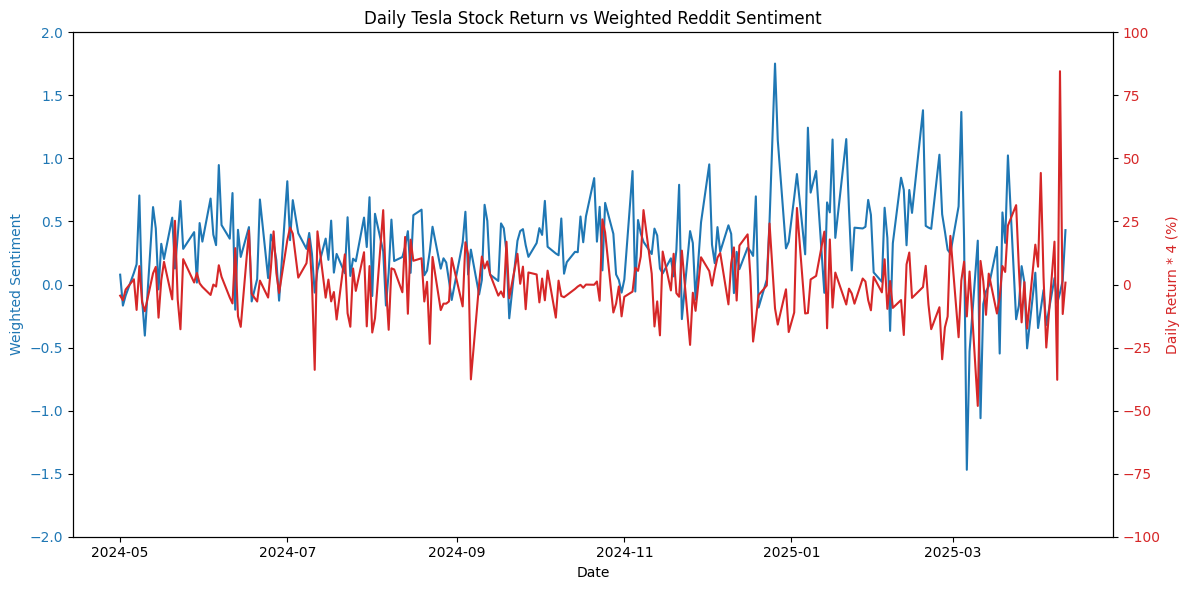

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取合并后的数据
df = pd.read_csv('/content/tesla_sentiment_daily_merged.csv', parse_dates=['Date'])

# 创建图形和双轴
fig, ax1 = plt.subplots(figsize=(12, 6))

# 左轴：情绪得分
ax1.set_xlabel('Date')
ax1.set_ylabel('Weighted Sentiment', color='tab:blue')
ax1.plot(df['Date'], df['weighted_sentiment'], color='tab:blue', label='Weighted Sentiment')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(-2, 2)  # 修改后的范围

# 右轴：股票回报率
ax2 = ax1.twinx()
ax2.set_ylabel('Daily Return * 4 (%)', color='tab:red')
ax2.plot(df['Date'], df['Daily_Return'] * 400, color='tab:red', label='Daily Return')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(-100, 100)

# 标题与图例
plt.title('Daily Tesla Stock Return vs Weighted Reddit Sentiment')
fig.tight_layout()

# 保存图片
plt.savefig('/content/sentiment_vs_return.png', dpi=300)

# 显示图片
plt.show()

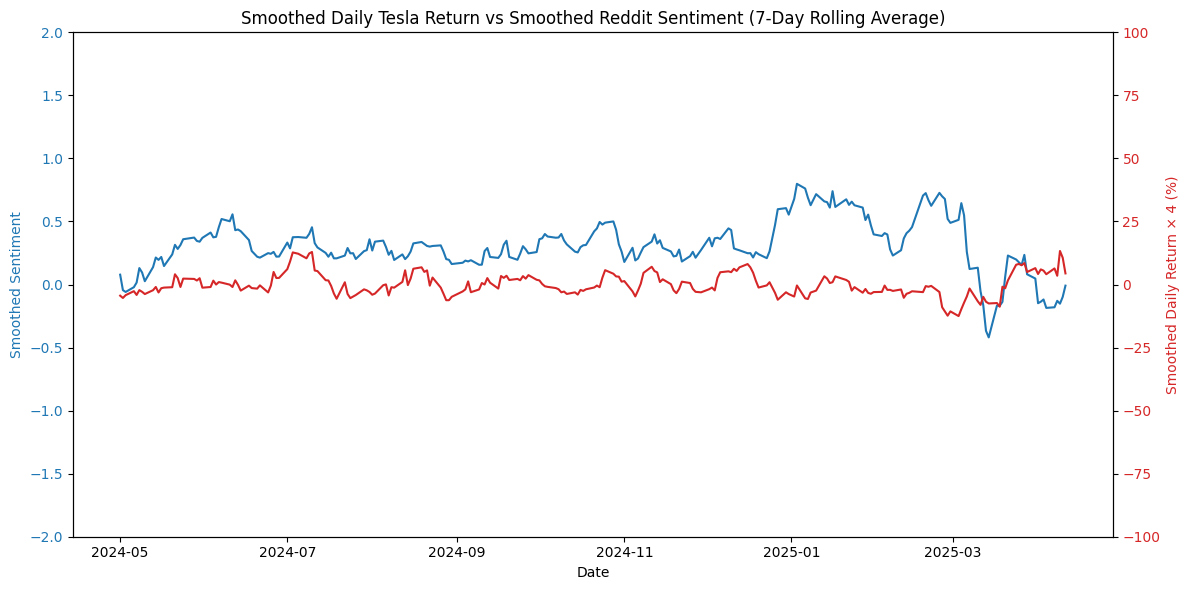

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('/content/tesla_sentiment_daily_merged.csv', parse_dates=['Date'])

# 计算滑动平均（窗口为7天）
df['sentiment_smooth'] = df['weighted_sentiment'].rolling(window=7, min_periods=1).mean()
df['return_smooth'] = df['Daily_Return'].rolling(window=7, min_periods=1).mean()

# 创建图形和双轴
fig, ax1 = plt.subplots(figsize=(12, 6))

# 左轴：平滑情绪
ax1.set_xlabel('Date')
ax1.set_ylabel('Smoothed Sentiment', color='tab:blue')
ax1.plot(df['Date'], df['sentiment_smooth'], color='tab:blue', label='Smoothed Sentiment')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(-2, 2)

# 右轴：平滑回报（乘以 4 便于视觉对比）
ax2 = ax1.twinx()
ax2.set_ylabel('Smoothed Daily Return × 4 (%)', color='tab:red')
ax2.plot(df['Date'], df['return_smooth'] * 400, color='tab:red', label='Smoothed Daily Return')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(-100, 100)

# 标题和布局
plt.title('Smoothed Daily Tesla Return vs Smoothed Reddit Sentiment (7-Day Rolling Average)')
fig.tight_layout()

# 保存图片
plt.savefig('/content/smoothed_sentiment_vs_return.png', dpi=300)

# 显示图
plt.show()